# Future Internet 2026: Reproduction Code
This notebook regenerates the paper's results tables and figures from the archived **run-level metrics** file, `robust_tsfms_rmse_picp_results_all_runs.csv`. You must have the `.csv` file in the same directory as this notebook. For your convenience you can choose the `Run All...` notebook option to run all cells. The outputs are written to the `reproduced_outputs/` directory, which include machine-readable tables, display tables, and PDF/EPS figures. This notebook also shows the tables and figures inline. If you have run the companion `robust_tsfms_experiment_runner.ipynb` notebook beforehand, you can set the `USE_REGENERATED` variable to `True` to utilize the generated `.csv` file.

In [11]:
from pathlib import Path
import hashlib
import platform

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

USE_REGENERATED = False  # Set True after running the companion inference notebook.
DATA_PATH = (
    Path('reproduced_outputs/regenerated/robust_tsfms_rmse_picp_results_all_runs.csv')
    if USE_REGENERATED else Path('robust_tsfms_rmse_picp_results_all_runs.csv')
)
OUTPUT_DIR = Path('reproduced_outputs')
FIGURE_DIR = OUTPUT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = ['Chronos-2', 'TimesFM-2.5', 'TiRex']
DATASET_ORDER = ['anomaly_free', 'valve1_0']
SCENARIO_ORDER = [
    'RPM 5%', 'RPM 10%', 'RPM 20%',
    'CBM 100', 'CBM 200', 'CBM 400',
    'PAI +2σ at 1%', 'PAI +3σ at 1%', 'PAI +5σ at 1%'
]
PAPER_VALVE1_SCENARIOS = [
    'RPM 20%', 'CBM 100', 'CBM 200', 'CBM 400', 'PAI +5σ at 1%'
]
CONDITION_ORDER = ['Clean'] + SCENARIO_ORDER

print('Python:', platform.python_version())
print('pandas:', pd.__version__, '| numpy:', np.__version__, '| matplotlib:', matplotlib.__version__)

Python: 3.14.7
pandas: 3.0.5 | numpy: 2.5.2 | matplotlib: 3.11.1


## 1. Load and audit the selected metrics

In [12]:
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f'Missing {DATA_PATH}. Place the archived run-level CSV beside this notebook.'
    )

raw = pd.read_csv(DATA_PATH)
required = ['Dataset', 'Target', 'Condition', 'Run', 'Model', 'RMSE', 'PICP80_%', 'n_windows']
missing_columns = set(required) - set(raw.columns)
if missing_columns:
    raise ValueError(f'Missing required CSV columns: {sorted(missing_columns)}')
if raw[required].isna().any().any():
    raise ValueError('The archived metrics contain missing values.')
if set(raw['Dataset']) != set(DATASET_ORDER):
    raise ValueError(f'Unexpected datasets: {sorted(set(raw.Dataset))}')
if set(raw['Model']) != set(MODEL_ORDER):
    raise ValueError(f'Unexpected models: {sorted(set(raw.Model))}')
if set(raw['Condition']) != set(CONDITION_ORDER):
    raise ValueError(f'Unexpected conditions: {sorted(set(raw.Condition))}')
if raw.duplicated(['Dataset', 'Target', 'Condition', 'Run', 'Model']).any():
    raise ValueError('Duplicate dataset–target–condition–run–model rows found.')
if not np.isfinite(raw[['RMSE', 'PICP80_%', 'n_windows']].to_numpy()).all():
    raise ValueError('Non-finite metric or window count found.')
if not raw['RMSE'].gt(0).all() or not raw['PICP80_%'].between(0, 100).all():
    raise ValueError('RMSE must be positive and PICP must be between 0 and 100.')

clean_rows = raw.loc[raw['Condition'].eq('Clean')].copy()
corrupt_rows = raw.loc[~raw['Condition'].eq('Clean')].copy()
run_ids = sorted(corrupt_rows['Run'].unique().tolist())
if run_ids != list(range(len(run_ids))):
    raise ValueError(f'Corrupted-run IDs are not contiguous from zero: {run_ids}')
if not clean_rows['Run'].eq(0).all():
    raise ValueError('Expected clean rows only at Run 0.')
if not clean_rows.groupby(['Dataset', 'Target', 'Model']).size().eq(1).all():
    raise ValueError('Expected one clean baseline for each dataset–target–model.')
if not corrupt_rows.groupby(['Dataset', 'Target', 'Condition', 'Model']).size().eq(len(run_ids)).all():
    raise ValueError('Incomplete corrupted runs for at least one dataset–target–condition–model.')
if not raw.groupby('Dataset')['Target'].nunique().eq(8).all():
    raise ValueError('Expected eight targets in each dataset.')
if len(clean_rows) != 2 * 8 * 3 or len(corrupt_rows) != 2 * 8 * 3 * 9 * len(run_ids):
    raise ValueError('Unexpected number of clean or corrupted rows.')
if not raw.groupby('Dataset')['n_windows'].nunique().eq(1).all():
    raise ValueError('n_windows varies within a dataset.')

digest = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print(f'Input: {DATA_PATH.resolve()}')
print(f'SHA-256: {digest}')
print(f'Rows: {len(raw):,} = {len(clean_rows):,} clean + {len(corrupt_rows):,} corrupted')
print(f'Corrupted runs: {len(run_ids)} ({run_ids[0]}–{run_ids[-1]})')
display(raw.groupby('Dataset').agg(
    targets=('Target', 'nunique'), windows_per_target=('n_windows', 'first')
))

Input: /Users/panas/Desktop/notebook_deliverables_mdpi/robust_tsfms_rmse_picp_results_all_runs.csv
SHA-256: c21e5ed07f112f3b129648b3222a2a1e1a3edc494d4f33c12ef276100920d684
Rows: 4,368 = 48 clean + 4,320 corrupted
Corrupted runs: 10 (0–9)


,targets,windows_per_target
Dataset,,
anomaly_free,8,73
valve1_0,8,5


## 2. Define the comparison metrics

In [13]:
baseline = clean_rows[['Dataset', 'Target', 'Model', 'RMSE']].rename(
    columns={'RMSE': 'RMSE_clean'}
)
metrics = corrupt_rows.merge(
    baseline, on=['Dataset', 'Target', 'Model'], validate='many_to_one', indicator=True
)
if not metrics['_merge'].eq('both').all():
    raise ValueError('Some corrupted rows lack a clean baseline.')
metrics = metrics.drop(columns='_merge')
metrics['RMSE_delta'] = 100 * (metrics['RMSE'] - metrics['RMSE_clean']) / metrics['RMSE_clean']
metrics['PICP_delta_pp'] = metrics['PICP80_%'] - 80
assert np.isfinite(metrics[['RMSE_delta', 'PICP_delta_pp']].to_numpy()).all()
print(f'Computed both comparison metrics for {len(metrics):,} corrupted rows.')

Computed both comparison metrics for 4,320 corrupted rows.


## 3. Table 2 — Anomaly-Free degradation summary

In [14]:
free_metrics = metrics.loc[metrics['Dataset'].eq('anomaly_free')].copy()

table2_numeric = (
    free_metrics.groupby(['Condition', 'Model'], sort=False)
    .agg(
        rmse_mean=('RMSE_delta', 'mean'), rmse_min=('RMSE_delta', 'min'),
        rmse_max=('RMSE_delta', 'max'),
        picp_mean=('PICP_delta_pp', 'mean'), picp_min=('PICP_delta_pp', 'min'),
        picp_max=('PICP_delta_pp', 'max'), n=('Target', 'size')
    )
    .reset_index()
)
assert len(table2_numeric) == len(SCENARIO_ORDER) * len(MODEL_ORDER)
assert table2_numeric['n'].eq(8 * len(run_ids)).all()

def signed_1dp(value):
    rounded = round(float(value), 1)
    return f'{0.0 if rounded == 0 else rounded:+.1f}'

def interval_text(center, low, high):
    return f'{signed_1dp(center)} [{signed_1dp(low)}, {signed_1dp(high)}]'

table2_display_long = table2_numeric.assign(
    RMSE_delta=lambda d: d.apply(
        lambda r: interval_text(r.rmse_mean, r.rmse_min, r.rmse_max), axis=1
    ),
    PICP_delta_pp=lambda d: d.apply(
        lambda r: interval_text(r.picp_mean, r.picp_min, r.picp_max), axis=1
    )
)
table2_display = (
    table2_display_long.melt(
        id_vars=['Condition', 'Model'], value_vars=['RMSE_delta', 'PICP_delta_pp'],
        var_name='Metric', value_name='mean [min, max]'
    )
    .pivot(index='Condition', columns=['Metric', 'Model'], values='mean [min, max]')
    .reindex(index=SCENARIO_ORDER)
    .reindex(columns=pd.MultiIndex.from_product(
        [['RMSE_delta', 'PICP_delta_pp'], MODEL_ORDER], names=['Metric', 'Model']
    ))
)
assert not table2_display.isna().any().any()
table2_numeric.to_csv(OUTPUT_DIR / 'table2_anomaly_free_numeric.csv', index=False)
table2_display.to_csv(OUTPUT_DIR / 'table2_anomaly_free_display.csv')
display(table2_display)

Metric                 RMSE_delta                                           \
Model                   Chronos-2          TimesFM-2.5               TiRex   
Condition                                                                    
RPM 5%          +0.9 [-1.6, +8.1]    +0.2 [-1.5, +3.0]   +0.8 [-1.5, +6.7]   
RPM 10%        +1.3 [-1.3, +10.9]    +0.4 [-1.7, +3.2]  +1.9 [-3.7, +12.1]   
RPM 20%        +1.8 [-1.5, +11.0]    +1.0 [-2.7, +5.9]  +3.0 [-3.0, +19.2]   
CBM 100        +1.1 [-3.9, +11.1]   +2.7 [-2.1, +13.1]   +1.2 [-4.0, +9.2]   
CBM 200        +2.7 [-0.6, +51.6]   +5.3 [-3.1, +33.7]  +3.1 [-2.1, +45.8]   
CBM 400        +7.9 [-1.3, +84.1]  +10.9 [-4.1, +69.0]  +7.8 [-0.6, +91.7]   
PAI +2σ at 1%   +0.5 [-1.6, +6.2]    +0.6 [-2.1, +6.0]   +0.3 [-0.9, +1.7]   
PAI +3σ at 1%   +0.5 [-1.9, +5.6]   +1.3 [-1.5, +14.3]   +0.6 [-0.2, +3.1]   
PAI +5σ at 1%   +0.8 [-1.3, +9.5]   +2.0 [-1.4, +18.6]   +1.1 [-0.4, +5.7]   

Metric             PICP_delta_pp                                         
Model                  Chronos-2         TimesFM-2.5              TiRex  
Condition                                                                
RPM 5%         -3.0 [-6.6, +0.0]   -0.9 [-3.2, +3.3]  -0.3 [-2.3, +2.0]  
RPM 10%        -3.4 [-7.6, -0.2]   -1.4 [-3.5, +3.5]  -0.8 [-3.7, +0.8]  
RPM 20%        -4.0 [-8.8, -1.1]   -2.1 [-5.1, +3.7]  -1.1 [-5.1, +0.8]  
CBM 100        -2.7 [-8.8, +0.7]   +0.3 [-2.8, +3.4]  +0.7 [-3.5, +6.4]  
CBM 200        -2.8 [-9.1, +1.8]   -0.1 [-4.9, +4.6]  +0.8 [-3.2, +6.6]  
CBM 400        -2.6 [-8.4, -0.2]  -0.3 [-10.8, +6.4]  +0.7 [-3.1, +5.0]  
PAI +2σ at 1%  -1.8 [-7.1, +3.1]   +0.6 [-1.6, +6.1]  +1.5 [-1.6, +7.7]  
PAI +3σ at 1%  -1.4 [-7.0, +3.3]   +1.2 [-1.4, +7.3]  +1.8 [-1.5, +8.3]  
PAI +5σ at 1%  -0.9 [-5.8, +4.0]   +1.6 [-1.3, +9.0]  +1.7 [-1.7, +8.0]

## 4. Figure 1 — Mean ΔRMSE by corruption severity

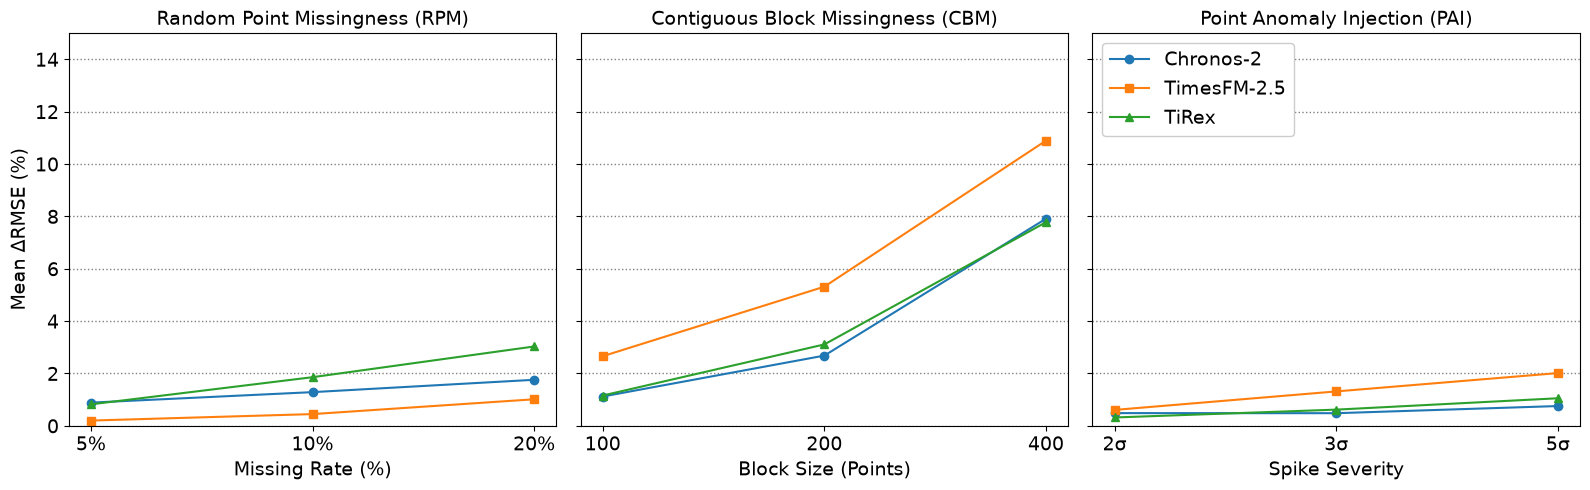

In [15]:
plot_means = (
    table2_numeric.pivot(index='Condition', columns='Model', values='rmse_mean')
    .reindex(columns=MODEL_ORDER)
)
groups = [
    ('Random Point Missingness (RPM)', ['RPM 5%', 'RPM 10%', 'RPM 20%'],
     ['5%', '10%', '20%'], 'Missing Rate (%)'),
    ('Contiguous Block Missingness (CBM)', ['CBM 100', 'CBM 200', 'CBM 400'],
     ['100', '200', '400'], 'Block Size (Points)'),
    ('Point Anomaly Injection (PAI)', ['PAI +2σ at 1%', 'PAI +3σ at 1%', 'PAI +5σ at 1%'],
     ['2σ', '3σ', '5σ'], 'Spike Severity')
]
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
styles = ['o-', 's-', '^-']
for ax, (title, conditions, labels, xlabel) in zip(axes, groups):
    panel = plot_means.reindex(index=conditions)
    for model, style in zip(MODEL_ORDER, styles):
        ax.plot(range(3), panel[model].to_numpy(), style, label=model)
    ax.set_xticks(range(3), labels)
    ax.set_ylim(0, 15)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(axis='y', linestyle=':', linewidth=1, color='gray')
axes[0].set_ylabel('Mean ΔRMSE (%)', fontsize=14)
axes[2].legend(loc='upper left', framealpha=1, fontsize=14)
fig.tight_layout()
for extension in ('pdf', 'eps'):
    fig.savefig(FIGURE_DIR / f'drmse-free.{extension}', bbox_inches='tight')
plt.show()

## 5. Figure 2 — Mean absolute 80% PICP

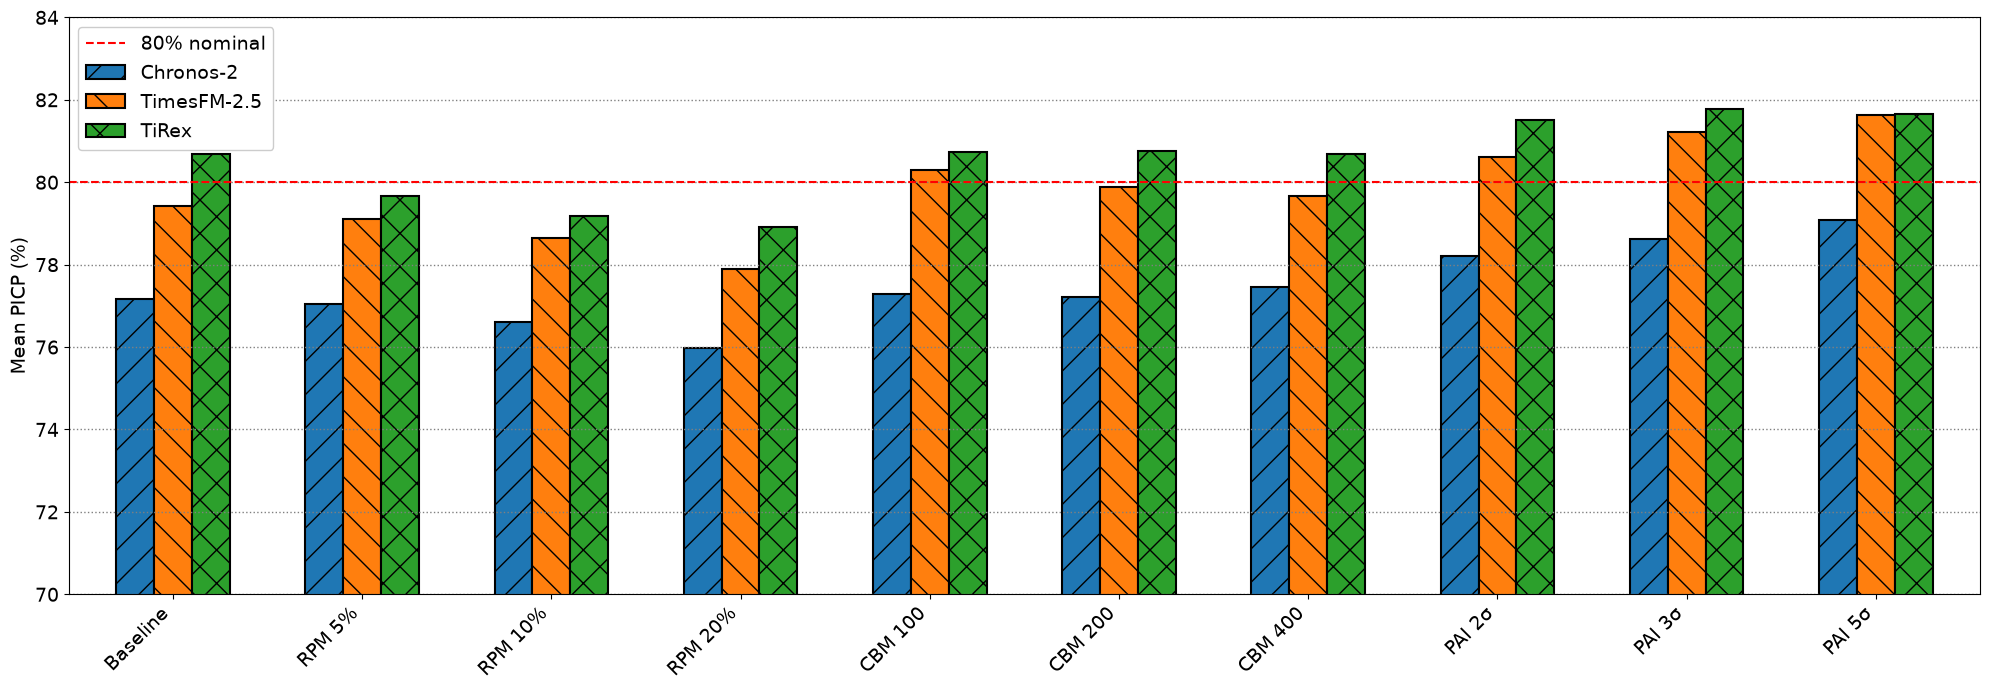

In [16]:
free_raw = raw.loc[raw['Dataset'].eq('anomaly_free')]
figure2_numeric = (
    free_raw.groupby(['Condition', 'Model'])['PICP80_%'].mean()
    .unstack('Model')
    .reindex(index=CONDITION_ORDER, columns=MODEL_ORDER)
)
assert not figure2_numeric.isna().any().any()
figure2_numeric.to_csv(OUTPUT_DIR / 'figure2_anomaly_free_picp.csv')

ax = figure2_numeric.plot.bar(
    ylim=(70, 84), width=0.6, figsize=(20, 7), fontsize=14,
    linewidth=1.5, edgecolor='black'
)
ax.set_ylabel('Mean PICP (%)', fontsize=14)
ax.set_xlabel(None)
ax.set_xticklabels(
    ['Baseline', 'RPM 5%', 'RPM 10%', 'RPM 20%',
     'CBM 100', 'CBM 200', 'CBM 400', 'PAI 2σ', 'PAI 3σ', 'PAI 5σ'],
    rotation=45, ha='right'
)
ax.axhline(80, color='red', linestyle='--', linewidth=1.5, label='80% nominal')
for hatch, container in zip(['/', '\\', 'x'], ax.containers[:3]):
    for patch in container.patches:
        patch.set_hatch(hatch)
ax.legend(loc='upper left', fontsize=14, framealpha=1)
ax.grid(axis='y', linestyle=':', linewidth=1, color='gray')
fig = ax.get_figure()
fig.tight_layout()
for extension in ('pdf', 'eps'):
    fig.savefig(FIGURE_DIR / f'picp-free.{extension}', bbox_inches='tight')
plt.show()

## 6. Cross-dataset pooled-mean diagnostic

In [17]:
comparison = (
    metrics.loc[metrics['Condition'].isin(PAPER_VALVE1_SCENARIOS)]
    .groupby(['Dataset', 'Condition', 'Model'])
    .agg(RMSE_delta=('RMSE_delta', 'mean'), PICP_delta_pp=('PICP_delta_pp', 'mean'))
    .reset_index()
)
comparison_index = pd.MultiIndex.from_product(
    [DATASET_ORDER, PAPER_VALVE1_SCENARIOS], names=['Dataset', 'Condition']
)
comparison_display = (
    comparison.pivot(index=['Dataset', 'Condition'], columns='Model',
                     values=['RMSE_delta', 'PICP_delta_pp'])
    .reindex(index=comparison_index)
    .reindex(columns=pd.MultiIndex.from_product(
        [['RMSE_delta', 'PICP_delta_pp'], MODEL_ORDER], names=['Metric', 'Model']
    ))
)
assert not comparison_display.isna().any().any()
comparison.to_csv(OUTPUT_DIR / 'cross_dataset_pooled_means_numeric.csv', index=False)
display(comparison_display.round(1))

Metric                     RMSE_delta                   PICP_delta_pp  \
Model                       Chronos-2 TimesFM-2.5 TiRex     Chronos-2   
Dataset      Condition                                                  
anomaly_free RPM 20%              1.8         1.0   3.0          -4.0   
             CBM 100              1.1         2.7   1.2          -2.7   
             CBM 200              2.7         5.3   3.1          -2.8   
             CBM 400              7.9        10.9   7.8          -2.6   
             PAI +5σ at 1%        0.8         2.0   1.1          -0.9   
valve1_0     RPM 20%              0.4         0.3   0.7          -1.1   
             CBM 100             -0.1         0.9   0.5          -0.4   
             CBM 200              1.7         3.4   1.8          -0.6   
             CBM 400              7.0        18.8   3.0          -1.1   
             PAI +5σ at 1%       -0.3         2.6  -1.3           0.6   

Metric                                        
Model                      TimesFM-2.5 TiRex  
Dataset      Condition                        
anomaly_free RPM 20%              -2.1  -1.1  
             CBM 100               0.3   0.7  
             CBM 200              -0.1   0.8  
             CBM 400              -0.3   0.7  
             PAI +5σ at 1%         1.6   1.7  
valve1_0     RPM 20%              -0.3  -0.2  
             CBM 100               1.4   2.9  
             CBM 200               1.3   3.4  
             CBM 400              -0.1   2.8  
             PAI +5σ at 1%         0.4   3.2

## 7. Valve 1 representative-run table

In [18]:
valve_metrics = metrics.loc[metrics['Dataset'].eq('valve1_0')].copy()
run_summary = (
    valve_metrics.groupby(['Dataset', 'Condition', 'Model', 'Run'])
    .agg(
        rmse_mean=('RMSE_delta', 'mean'), rmse_min=('RMSE_delta', 'min'),
        rmse_max=('RMSE_delta', 'max'),
        picp_mean=('PICP_delta_pp', 'mean'), picp_min=('PICP_delta_pp', 'min'),
        picp_max=('PICP_delta_pp', 'max'), targets=('Target', 'nunique')
    )
    .reset_index()
)
assert run_summary['targets'].eq(8).all()
assert run_summary.groupby(['Condition', 'Model'])['Run'].nunique().eq(len(run_ids)).all()

selected_rank = (len(run_ids) + 1) // 2  # lower central run for an even run count

def pick_ranked_run(metric):
    center = f'{metric}_mean'
    ranked = run_summary.sort_values(['Condition', 'Model', center, 'Run']).copy()
    ranked['rank'] = ranked.groupby(['Condition', 'Model']).cumcount() + 1
    picked = ranked.loc[ranked['rank'].eq(selected_rank)].copy()
    picked['Metric'] = 'RMSE_delta' if metric == 'rmse' else 'PICP_delta_pp'
    picked['center'] = picked[center]
    picked['minimum'] = picked[f'{metric}_min']
    picked['maximum'] = picked[f'{metric}_max']
    return picked[['Dataset', 'Condition', 'Model', 'Metric', 'Run', 'rank',
                   'targets', 'center', 'minimum', 'maximum']]

selected_runs = pd.concat(
    [pick_ranked_run('rmse'), pick_ranked_run('picp')], ignore_index=True
)
assert len(selected_runs) == len(SCENARIO_ORDER) * len(MODEL_ORDER) * 2
assert selected_runs['rank'].eq(selected_rank).all()
selected_runs['mean [min, max]'] = selected_runs.apply(
    lambda r: interval_text(r.center, r.minimum, r.maximum), axis=1
)
table3_all = (
    selected_runs.pivot(index='Condition', columns=['Metric', 'Model'],
                        values='mean [min, max]')
    .reindex(index=SCENARIO_ORDER)
    .reindex(columns=pd.MultiIndex.from_product(
        [['RMSE_delta', 'PICP_delta_pp'], MODEL_ORDER], names=['Metric', 'Model']
    ))
)
assert not table3_all.isna().any().any()
table3_paper = table3_all.reindex(index=PAPER_VALVE1_SCENARIOS)
selected_runs.to_csv(OUTPUT_DIR / 'valve1_selected_runs_numeric.csv', index=False)
table3_all.to_csv(OUTPUT_DIR / 'valve1_all_scenarios_display.csv')
table3_paper.to_csv(OUTPUT_DIR / 'table3_valve1_paper_scenarios_display.csv')

display(Markdown('**All nine Valve 1 scenarios**'))
display(table3_all)
display(Markdown('**Five scenarios used in the paper table**'))
display(table3_paper)
print(f'Selected rank: {selected_rank} of {len(run_ids)} (1-based; lower central).')

**All nine Valve 1 scenarios**

Metric                 RMSE_delta                                            \
Model                   Chronos-2           TimesFM-2.5               TiRex   
Condition                                                                     
RPM 5%          +0.0 [-5.9, +4.7]     -0.2 [-2.8, +1.3]   -0.3 [-2.0, +0.8]   
RPM 10%         +0.4 [-3.1, +6.3]     +0.0 [-1.9, +2.0]   +0.1 [-1.2, +2.0]   
RPM 20%         +0.0 [-2.2, +2.6]     +0.2 [-2.2, +4.6]   +0.6 [-3.4, +3.3]   
CBM 100         -0.6 [-6.9, +4.7]     +0.7 [-5.7, +4.3]   +0.2 [-0.4, +1.1]   
CBM 200        +1.4 [-8.5, +16.8]    +3.4 [-3.8, +15.2]   +1.3 [+0.0, +3.6]   
CBM 400        +7.1 [+0.0, +24.8]  +17.4 [-0.1, +111.2]  +3.3 [-4.4, +13.7]   
PAI +2σ at 1%   -0.4 [-5.6, +2.4]    +1.8 [-0.2, +12.1]   -0.8 [-4.8, +0.1]   
PAI +3σ at 1%   -0.2 [-5.4, +4.5]     +2.1 [-0.1, +9.6]   -1.0 [-6.0, +0.5]   
PAI +5σ at 1%   -0.3 [-4.0, +2.9]    +2.5 [-0.3, +13.8]   -1.3 [-9.6, +0.4]   

Metric               PICP_delta_pp                                          
Model                    Chronos-2         TimesFM-2.5               TiRex  
Condition                                                                   
RPM 5%         -0.5 [-11.7, +14.7]  +0.2 [-8.0, +16.3]   +1.7 [-9.3, +8.0]  
RPM 10%        -0.7 [-12.3, +12.7]  +0.1 [-8.0, +16.7]  +0.3 [-11.3, +7.0]  
RPM 20%         -1.2 [-11.3, +7.0]  -0.4 [-7.7, +15.7]  -0.5 [-13.0, +7.0]  
CBM 100        -0.3 [-11.3, +15.7]  +1.3 [-7.0, +16.3]  +2.7 [-2.3, +11.7]  
CBM 200        -0.5 [-13.3, +14.0]  +1.4 [-5.7, +18.3]  +3.0 [-3.0, +16.7]  
CBM 400          -1.1 [-9.7, +8.7]   -0.3 [-6.0, +6.0]  +2.8 [-2.3, +14.0]  
PAI +2σ at 1%  -0.4 [-12.3, +16.7]   -0.3 [-7.7, +7.0]  +3.3 [-2.3, +11.7]  
PAI +3σ at 1%  -0.1 [-12.7, +15.0]   -0.1 [-6.3, +6.3]  +3.3 [-2.0, +12.7]  
PAI +5σ at 1%   +0.7 [-8.7, +15.3]   +0.2 [-4.3, +4.0]  +3.2 [-3.7, +12.7]

**Five scenarios used in the paper table**

Metric                 RMSE_delta                                            \
Model                   Chronos-2           TimesFM-2.5               TiRex   
Condition                                                                     
RPM 20%         +0.0 [-2.2, +2.6]     +0.2 [-2.2, +4.6]   +0.6 [-3.4, +3.3]   
CBM 100         -0.6 [-6.9, +4.7]     +0.7 [-5.7, +4.3]   +0.2 [-0.4, +1.1]   
CBM 200        +1.4 [-8.5, +16.8]    +3.4 [-3.8, +15.2]   +1.3 [+0.0, +3.6]   
CBM 400        +7.1 [+0.0, +24.8]  +17.4 [-0.1, +111.2]  +3.3 [-4.4, +13.7]   
PAI +5σ at 1%   -0.3 [-4.0, +2.9]    +2.5 [-0.3, +13.8]   -1.3 [-9.6, +0.4]   

Metric               PICP_delta_pp                                          
Model                    Chronos-2         TimesFM-2.5               TiRex  
Condition                                                                   
RPM 20%         -1.2 [-11.3, +7.0]  -0.4 [-7.7, +15.7]  -0.5 [-13.0, +7.0]  
CBM 100        -0.3 [-11.3, +15.7]  +1.3 [-7.0, +16.3]  +2.7 [-2.3, +11.7]  
CBM 200        -0.5 [-13.3, +14.0]  +1.4 [-5.7, +18.3]  +3.0 [-3.0, +16.7]  
CBM 400          -1.1 [-9.7, +8.7]   -0.3 [-6.0, +6.0]  +2.8 [-2.3, +14.0]  
PAI +5σ at 1%   +0.7 [-8.7, +15.3]   +0.2 [-4.3, +4.0]  +3.2 [-3.7, +12.7]

Selected rank: 5 of 10 (1-based; lower central).


## 8. Reproduction checks and output files

In [19]:
# Figure 1 uses Table 2 means exactly; Figure 2's corrupted bars imply Table 2
# ΔPICP means because both average the same rows and subtract the fixed 80% target.
for _, row in table2_numeric.iterrows():
    condition, model = row['Condition'], row['Model']
    assert np.isclose(plot_means.loc[condition, model], row['rmse_mean'])
    assert np.isclose(figure2_numeric.loc[condition, model] - 80, row['picp_mean'])
assert table3_paper.shape == (5, 6)
assert table2_display.shape == (9, 6)

print('Checks passed: complete input, matched clean baselines, figures/table consistency,')
print('and expected Table 2 / Valve 1 paper-table dimensions.')
print('Generated files:')
for path in sorted(OUTPUT_DIR.rglob('*')):
    if path.is_file():
        print(' ', path.as_posix())

Checks passed: complete input, matched clean baselines, figures/table consistency,
and expected Table 2 / Valve 1 paper-table dimensions.
Generated files:
  reproduced_outputs/cross_dataset_pooled_means_numeric.csv
  reproduced_outputs/figure2_anomaly_free_picp.csv
  reproduced_outputs/figures/drmse-free.eps
  reproduced_outputs/figures/drmse-free.pdf
  reproduced_outputs/figures/picp-free.eps
  reproduced_outputs/figures/picp-free.pdf
  reproduced_outputs/table2_anomaly_free_display.csv
  reproduced_outputs/table2_anomaly_free_numeric.csv
  reproduced_outputs/table3_valve1_paper_scenarios_display.csv
  reproduced_outputs/valve1_all_scenarios_display.csv
  reproduced_outputs/valve1_selected_runs_numeric.csv
